<a href="https://colab.research.google.com/github/bhakya01/Social_media/blob/main/social_media.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Import & Setup

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
 from

In [ ]:
from google.colab import files
import pandas as pd

# Upload the CSV file
uploaded = files.upload()

# Read the uploaded CSV file
df = pd.read_csv("social_media.csv")
# Display first 5 rows
df

Saving social_media.csv to social_media.csv


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


Check/convert data types

In [ ]:
df.dtypes

,0
user_id,object
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


Convert date columns to datetime

In [ ]:
df['posted_at	'] = pd.to_datetime (df['posted_at'],errors='coerce')

/tmp/ipykernel_4229/1759657305.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at	'] = pd.to_datetime (df['posted_at'],errors='coerce')


— Data Cleaning

Detect missing values (isnull(), isna())

In [ ]:
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [ ]:
df.isna().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


Handle using:

In [ ]:
# Fill numerical missing values with median
df['likes'] = df['likes'].fillna(df['likes'].median())
df['comments'] = df['comments'].fillna(df['comments'].median())
df['shares'] = df['shares'].fillna(df['shares'].median())
print(df[['likes','comments','shares']].sum())

likes       50534987.0
comments     7510199.0
shares       5014553.0
dtype: float64


In [ ]:
df.describe()

,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,posted_at\t
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000
mean,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,393698.224800,0.964356,2022-12-28 13:21:30.240000
min,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,87.000000,0.006363,2022-01-01 00:00:00
25%,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,194480.000000,0.145781,2022-07-03 18:00:00
50%,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,388982.000000,0.253896,2022-12-27 00:00:00
75%,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,589744.250000,0.504794,2023-06-28 00:00:00
max,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,799533.000000,191.504348,2023-12-31 00:00:00
std,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,230927.884535,5.318029,NaN


Duplicate Handling

In [ ]:
# Create a copy and remove rows with missing values
df_dropna = df.dropna()

print("Original rows:", len(df))
print("Rows after dropna:", len(df_dropna))

Original rows: 5000
Rows after dropna: 4562


Data Formatting

In [ ]:
# Forward fill
df_ffill = df.ffill()

# Backward fill
df_bfill = df.bfill()
print(df_ffill)
print(df_bfill)

     user_id   age  gender    country  post_id post_type post_category  \
0      25795  43.0  Female     Brazil   496713     image       fitness   
1      10860  33.0    Male     Brazil   157326      reel          food   
2      86820  32.0  Female         UK   109864      text          food   
3      64886  51.0   Other     France   848877      text       fitness   
4      16265  34.0   Other         UK   449706     image       fitness   
...      ...   ...     ...        ...      ...       ...           ...   
4995   59500  44.0    Male  Australia   441541     video     education   
4996   22100  38.0   Other        UAE   677076      reel     education   
4997   67021  63.0  Female        USA   273595      text        travel   
4998   29800  13.0  Female    Germany   785644     video       fitness   
4999   73400  54.0   Other      Japan   712252      text        travel   

        likes  comments  shares  watch_time_sec  impression_count   posted_at  \
0      7011.0     354.0  1157.

In [ ]:
df['posted_at'] = df['posted_at'].ffill()
df['posted_at'] = df['posted_at'].bfill()

In [ ]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
user_id               0
age                   0
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes                 0
comments              0
shares                0
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
posted_at\t           0
dtype: int64


In [ ]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])
print("\nAfter handling:")
print(df[['gender', 'sentiment']].isnull().sum())


After handling:
gender       0
sentiment    0
dtype: int64


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [ ]:
print(df.dtypes)


user_id                     object
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at                   object
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
posted_at\t         datetime64[ns]
dtype: object


Standardize categories

In [ ]:

categorical_cols = [
    'gender',
    'country',
    'post_type',
    'post_category',
    'device_type',
    'sentiment'
]

for col in categorical_cols:
    df[col] = df[col].str.strip().str.lower()

In [ ]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


gender:
gender
male      1699
other     1581
female    1570
Name: count, dtype: int64

country:
country
india        535
canada       513
brazil       504
uae          503
usa          501
france       496
uk           493
australia    493
germany      490
japan        472
Name: count, dtype: int64

post_type:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

post_category:
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64

device_type:
device_type
mobile     1684
tablet     1658
desktop    1658
Name: count, dtype: int64

sentiment:
sentiment
positive    2363
neutral     1527
negative     960
Name: count, dtype: int64


Correct unrealistic values in likes, comments, shares

In [ ]:
print("Negative likes:", (df['likes'] < 0).sum())
print("Negative comments:", (df['comments'] < 0).sum())
print("Negative shares:", (df['shares'] < 0).sum())

Negative likes: 0
Negative comments: 0
Negative shares: 0


Feature Cleaning

In [ ]:
print(df['hashtags'].head(10))

0      #foodie #travel #love
1                   #fitness
2                    #foodie
3        #music #foodie #fun
4                    #travel
5                   #fitness
6                     #music
7    #travel #music #fitness
8       #music #fun #fitness
9           #lifestyle #love
Name: hashtags, dtype: object


Clean sentiment labels

In [ ]:
# Remove extra spaces and convert to lowercase
df['sentiment'] = df['sentiment'].str.strip().str.lower()

# Standardize sentiment labels
df['sentiment'] = df['sentiment'].replace({
    'pos': 'Positive',
    'positive': 'Positive',
    'neg': 'Negative',
    'negative': 'Negative',
    'neu': 'Neutral',
    'neutral': 'Neutral'

})
print(df['sentiment'] )

0       Negative
1       Negative
2       Positive
3       Negative
4       Negative
          ...   
4995    Positive
4996    Negative
4997    Positive
4998    Positive
4999     Neutral
Name: sentiment, Length: 5000, dtype: object


Data Exploration using Pandas
View dataset structure

In [ ]:
print("\n Firt five rows:")
display(df.head())
print("\n Last five rows:")
display(df.tail())
print("\n Dataset Shape:")
print(df.shape)
print("\n Column Names:")
print(df.columns.tolist())


 Firt five rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,posted_at\t
0,25795,43.0,female,brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862,2022-12-17
1,10860,33.0,male,brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493,2023-06-02
2,86820,32.0,female,uk,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345,2023-05-07
3,64886,51.0,other,france,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195,2023-02-12
4,16265,34.0,other,uk,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372,2023-05-23



 Last five rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,posted_at\t
4995,59500,44.0,male,australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761,2022-06-25
4996,22100,38.0,other,uae,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155,2022-11-18
4997,67021,63.0,female,usa,273595,text,travel,13487.0,1497.0,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688,2023-04-06
4998,29800,13.0,female,germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518,2022-05-16
4999,73400,54.0,other,japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,2023-03-04



 Dataset Shape:
(5000, 20)

 Column Names:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'posted_at\t']


Check data types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   object        
 1   age               4850 non-null   float64       
 2   gender            4850 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   object        
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
df.dtypes

,0
user_id,object
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


Analyze categorical

In [ ]:
# Count each category (includes missing values if dropna=False)


print("Value counts (normalized):")
print(df["post_category"].value_counts(normalize=True,dropna=False))

# List the distinct values
print("\n Unique values:")
print(df["post_category"].unique())

# Count the number of distinct values
print("\n Number of unique values:")
print(df["post_category"].nunique(dropna=False))


Value counts (normalized):
post_category
fitness      0.1350
tech         0.1330
music        0.1270
education    0.1262
lifestyle    0.1214
travel       0.1200
fashion      0.1188
food         0.1186
Name: proportion, dtype: float64

 Unique values:
['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']

 Number of unique values:
8


In [ ]:
# Calculate Pearson correlation matrix for numeric fields
numeric_cols = df.select_dtypes(include=['number'])
corr_matrix = numeric_cols.corr(method='pearson')

# Display the correlation matrix
print("Pearson Correlation Matrix:")
display(corr_matrix)

Pearson Correlation Matrix:


,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,age_rounded
age,1.000000,-0.013353,-0.036767,-0.007369,0.014120,0.005677,0.013513,-0.025416,0.008044,1.000000
post_id,-0.013353,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,-0.013353
likes,-0.036767,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.036767
comments,-0.007369,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.007369
shares,0.014120,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.014120
watch_time_sec,0.005677,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,0.005677
impression_count,0.013513,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,0.013513
follower_count,-0.025416,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,-0.025416
engagement_rate,0.008044,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.008044
age_rounded,1.000000,-0.013353,-0.036767,-0.007369,0.014120,0.005677,0.013513,-0.025416,0.008044,1.000000


Use groupby

In [ ]:
# Calculate average likes and engagement rate by post type
post_type_summary = df.groupby('post_type')[['likes', 'engagement_rate']].mean()
print("Average Metrics by Post Type:")
display(post_type_summary)

# Calculate total and average impressions by country
country_summary = df.groupby('country')['impression_count'].agg(['sum', 'mean']).rename(columns={'sum': 'total_impressions', 'mean': 'avg_impressions'})
print("\nImpressions by Country:")
display(country_summary)

Average Metrics by Post Type:


,likes,engagement_rate
post_type,,
image,10104.865277,0.895646
reel,10037.802416,0.783047
text,10100.148193,1.064549
video,10188.600000,1.122365



Impressions by Country:


,total_impressions,avg_impressions
country,,
australia,23834767,48346.383367
brazil,24793360,49193.174603
canada,24984716,48703.150097
france,25656926,51727.673387
germany,23816649,48605.406122
india,28067377,52462.386916
japan,23418816,49616.135593
uae,24610992,48928.413519
uk,25201861,51119.393509


Data Wrangling

In [ ]:
# 1. Example of pd.concat: Combining two subsets of our main DataFrame (e.g., Teens and Seniors)
teens_df = df[df['age_group'] == 'Teens (<20)'].head(3)
seniors_df = df[df['age_group'] == 'Seniors (51+)'].head(3)

combined_subsets = pd.concat([teens_df, seniors_df], axis=0)
print("1. Combined Subsets (pd.concat along rows):")
display(combined_subsets[['user_id', 'age', 'age_group']])

# 2. Example of pd.merge: Merging our post_type_summary metrics back into a sample of the main DataFrame
sample_df = df[['user_id', 'post_type', 'likes']].head(5)
merged_df = pd.merge(sample_df, post_type_summary, on='post_type', suffixes=('_original', '_avg_for_type'))

print("\n2. Merged DataFrame (pd.merge adding group-level averages to sample rows):")
display(merged_df)

1. Combined Subsets (pd.concat along rows):


,user_id,age,age_group
5,92386,16.0,Teens (<20)
17,74925,13.0,Teens (<20)
39,13890,14.0,Teens (<20)
3,64886,51.0,Seniors (51+)
7,97498,57.0,Seniors (51+)
8,54131,54.0,Seniors (51+)



2. Merged DataFrame (pd.merge adding group-level averages to sample rows):


,user_id,post_type,likes_original,likes_avg_for_type,engagement_rate
0,25795,image,7011.0,10104.865277,0.895646
1,10860,reel,11750.0,10037.802416,0.783047
2,86820,text,4862.0,10100.148193,1.064549
3,64886,text,5350.0,10100.148193,1.064549
4,16265,image,12682.0,10104.865277,0.895646


In [ ]:
# Show the newly created features summary
display(df[['engagement_rate', 'likes', 'hashtags']].describe())
print("\nUpdated Column List:")
print(df.columns.tolist())

,engagement_rate,likes
count,5000.000000,5000.000000
mean,0.964356,10106.997400
std,5.318029,5702.293017
min,0.006363,10.000000
25%,0.145781,5235.000000
50%,0.253896,10105.500000
75%,0.504794,14959.000000
max,191.504348,19998.000000



Updated Column List:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'posted_at\t', 'age_rounded', 'age_group', 'engagement_score']


In [ ]:
import numpy as np
import pandas as pd

# 1. Create engagement_score (likes + 2*comments + 3*shares)
df['engagement_score'] = df['likes'] + (df['comments'] * 2) + (df['shares'] * 3)

# 2. Log-transformed metric for highly skewed numeric data
df['log_likes'] = np.log1p(df['likes'])

# 3. Calculate hashtag count (number of space-separated tags, 0 if null)
df['hashtag_count'] = df['hashtags'].apply(lambda x: len(str(x).split()) if pd.notnull(x) and str(x).strip() != '' else 0)

# Preview the resulting dataset with newly created features
display(df[['likes', 'comments', 'shares', 'engagement_score', 'log_likes', 'hashtags', 'hashtag_count']].head(5))

,likes,comments,shares,engagement_score,log_likes,hashtags,hashtag_count
0,7011.0,354.0,1157.0,11190.0,8.855378,#foodie #travel #love,3
1,11750.0,2606.0,1807.0,22383.0,9.371694,#fitness,1
2,4862.0,344.0,955.0,8415.0,8.489411,#foodie,1
3,5350.0,1083.0,1049.0,10663.0,8.585039,#music #foodie #fun,3
4,12682.0,2735.0,1300.0,22052.0,9.448018,#travel,1


In [ ]:
# Groupby summaries by post_type, country, and sentiment
import pandas as pd

# 1. Summary by Post Type
print("=== Summary by Post Type ===")
post_type_grp = df.groupby('post_type')[['likes', 'comments', 'shares', 'engagement_score']].mean()
display(post_type_grp)

# 2. Summary by Country
print("\n=== Summary by Country ===")
country_grp = df.groupby('country')[['likes', 'comments', 'shares', 'engagement_score']].mean()
display(country_grp)

# 3. Summary by Sentiment
print("\n=== Summary by Sentiment ===")
sentiment_grp = df.groupby('sentiment')[['likes', 'comments', 'shares', 'engagement_score']].mean()
display(sentiment_grp)

# 4. Multi-level Groupby: Post Type & Sentiment
print("\n=== Summary by Post Type and Sentiment ===")
multi_grp = df.groupby(['post_type', 'sentiment'])[['likes', 'engagement_score']].mean().reset_index()
display(multi_grp.head(10))

=== Summary by Post Type ===


,likes,comments,shares,engagement_score
post_type,,,,
image,10104.865277,1525.235766,1019.289495,16213.205293
reel,10037.802416,1504.187062,982.042089,15992.302806
text,10100.148193,1499.106024,1013.989558,16140.328916
video,10188.600000,1479.160000,996.834286,16137.422857



=== Summary by Country ===


,likes,comments,shares,engagement_score
country,,,,
australia,10294.124746,1485.803245,1029.693712,16354.812373
brazil,9886.689484,1490.434524,1008.859127,15894.135913
canada,10063.066277,1546.582846,996.245614,16144.968811
france,10372.876008,1478.695565,1051.812500,16485.704637
germany,10130.458163,1531.826531,973.379592,16114.250000
india,9962.468224,1494.917757,1035.315888,16058.251402
japan,10088.862288,1530.434322,959.351695,16027.786017
uae,10227.487078,1541.214712,989.075547,16277.143141
uk,9935.650101,1463.042596,985.681542,15818.779919



=== Summary by Sentiment ===


,likes,comments,shares,engagement_score
sentiment,,,,
negative,10208.096875,1516.094792,1007.307292,16262.208333
neutral,9923.194499,1528.404060,996.565160,15969.698101
positive,10156.926788,1482.401608,1001.880660,16127.371985



=== Summary by Post Type and Sentiment ===


,post_type,sentiment,likes,engagement_score
0,image,negative,9921.936652,15985.502262
1,image,neutral,9870.773902,16045.921189
2,image,positive,10292.492399,16381.882601
3,reel,negative,10630.849020,16662.558824
4,reel,neutral,9890.786082,16030.291237
5,reel,positive,9887.718391,15678.380131
6,text,negative,9983.344017,16052.540598
7,text,neutral,9932.013854,15894.316121
8,text,positive,10207.983478,16296.880870
9,video,negative,10240.224000,16294.708000


Statistical Analysis

In [ ]:
# Map columns to the exact names present in the DataFrame
target_cols = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']

# Compute standard descriptive statistics using pandas
stats_df = df[target_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T

# Calculate additional statistics: Median, Mode, Variance, Skewness, and Kurtosis
stats_df['median'] = df[target_cols].median()
stats_df['mode'] = df[target_cols].mode().iloc[0]  # Take the first mode if multiple exist
stats_df['var'] = df[target_cols].var()
stats_df['skewness'] = df[target_cols].skew()
stats_df['kurtosis'] = df[target_cols].kurt()

# Reorganize and rename the columns for a clean presentation
stats_summary = stats_df[[
    'mean', 'median', 'mode',
    'std', 'var',
    '25%', '50%', '75%', '90%', '95%', '99%',
    'skewness', 'kurtosis'
]]

print("=== Descriptive Statistics Summary ===")
display(stats_summary)

=== Descriptive Statistics Summary ===


,mean,median,mode,std,var,25%,50%,75%,90%,95%,99%,skewness,kurtosis
likes,10106.997400,10105.500000,10105.500000,5702.293017,3.251615e+07,5235.000000,10105.500000,14959.000000,18016.3000,19097.050000,19857.020000,-0.006894,-1.149992
comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05,792.000000,1497.000000,2235.250000,2695.1000,2861.000000,2975.010000,0.003802,-1.144375
shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05,511.000000,1012.000000,1483.000000,1795.1000,1901.050000,1983.000000,-0.014654,-1.146857
watch_time_sec,4014.503200,4034.500000,916.000000,2308.096459,5.327309e+06,2017.750000,4034.500000,6020.250000,7212.1000,7577.050000,7924.040000,-0.018196,-1.195652
engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01,0.145781,0.253896,0.504794,1.2012,2.328526,13.672022,18.781271,482.991739
follower_count,393698.224800,388982.000000,497502.000000,230927.884535,5.332769e+10,194480.000000,388982.000000,589744.250000,717755.9000,760174.350000,792524.700000,0.041118,-1.189474


 Data Visualization
 Scatter


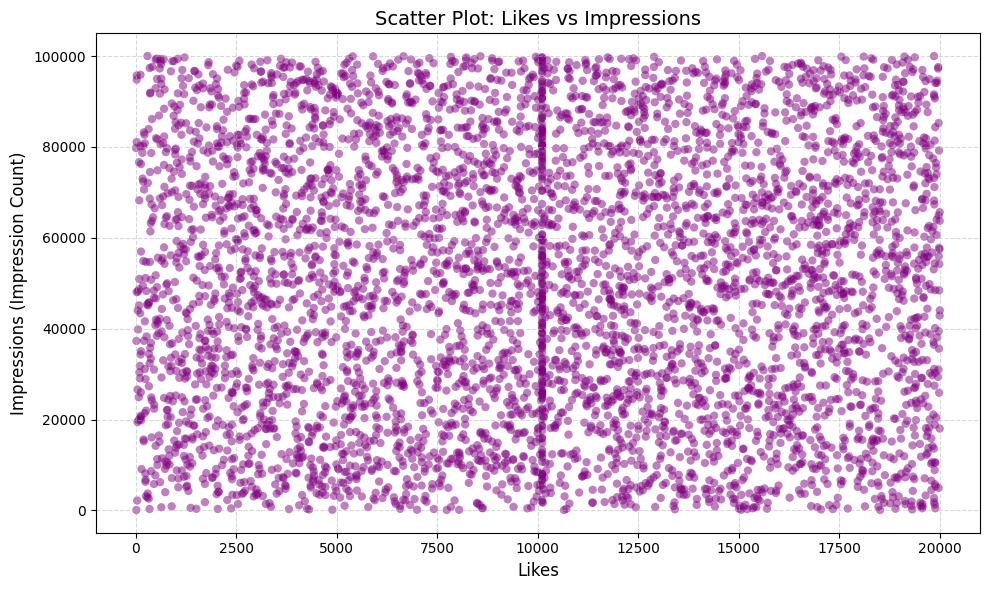

In [ ]:
import matplotlib.pyplot as plt

# Create a scatter plot of likes vs impressions
plt.figure(figsize=(10, 6))
plt.scatter(df['likes'], df['impression_count'], alpha=0.5, color='purple', edgecolors='none')

# Add titles and labels
plt.title('Scatter Plot: Likes vs Impressions', fontsize=14)
plt.xlabel('Likes', fontsize=12)
plt.ylabel('Impressions (Impression Count)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Display the plot
plt.tight_layout()
plt.show()

Line

/tmp/ipykernel_4229/2756672943.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_date'] = pd.to_datetime(df['posted_at'], errors='coerce')


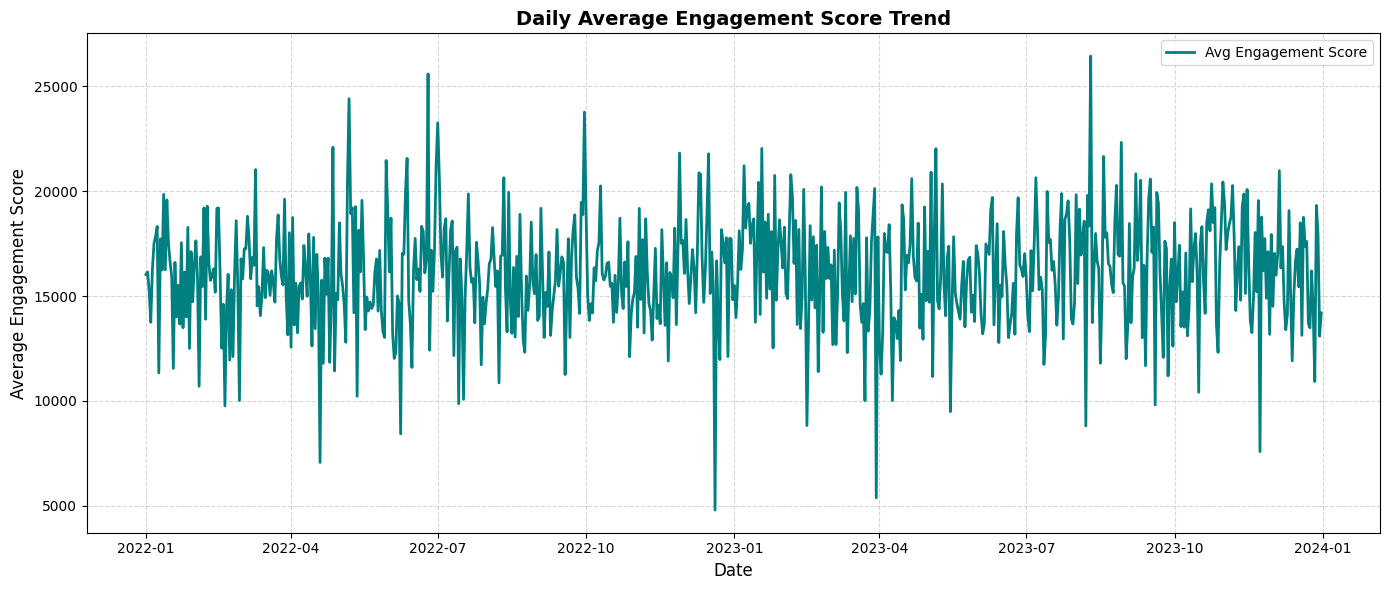

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure the date column is in datetime format
df['posted_date'] = pd.to_datetime(df['posted_at'], errors='coerce')

# Group by the date and calculate mean engagement metrics
daily_trends = df.groupby('posted_date')[['engagement_score', 'likes']].mean().reset_index()

# Plot the daily engagement score trend
plt.figure(figsize=(14, 6))
plt.plot(daily_trends['posted_date'], daily_trends['engagement_score'], color='teal', linewidth=2, label='Avg Engagement Score')

# Add titles, labels, and clean up formatting
plt.title('Daily Average Engagement Score Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Engagement Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Bar

/tmp/ipykernel_4229/898256953.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='post_category', data=category_counts, palette='viridis')


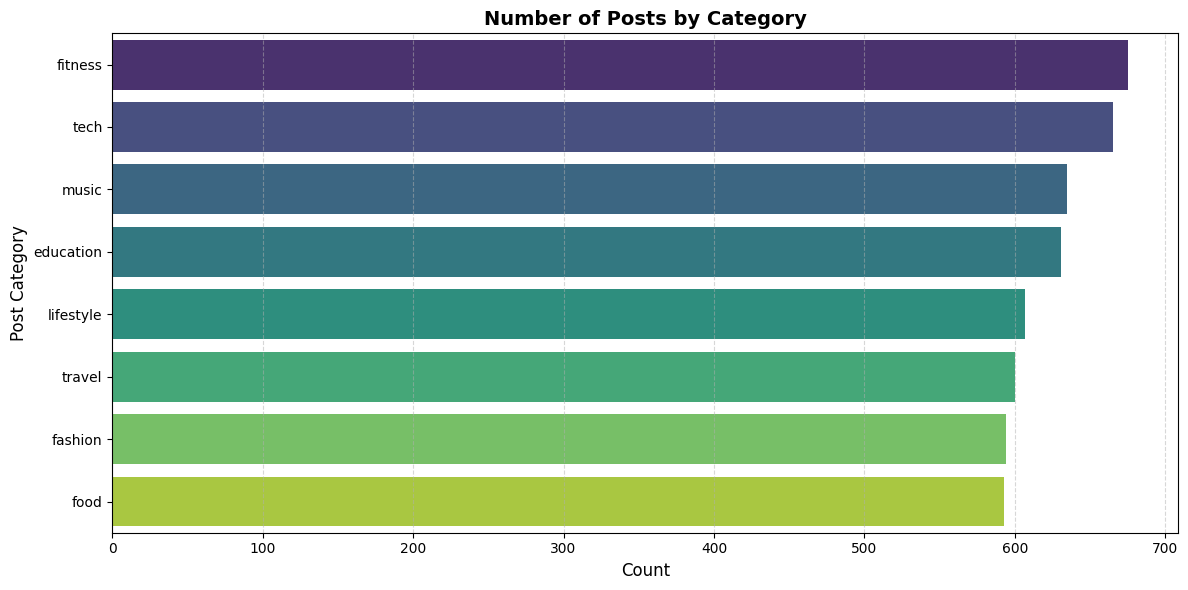

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate counts for each post category
category_counts = df['post_category'].value_counts().reset_index()
category_counts.columns = ['post_category', 'count']

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='post_category', data=category_counts, palette='viridis')

# Add titles and labels
plt.title('Number of Posts by Category', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Post Category', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

# Display the plot
plt.tight_layout()
plt.show()

Pie

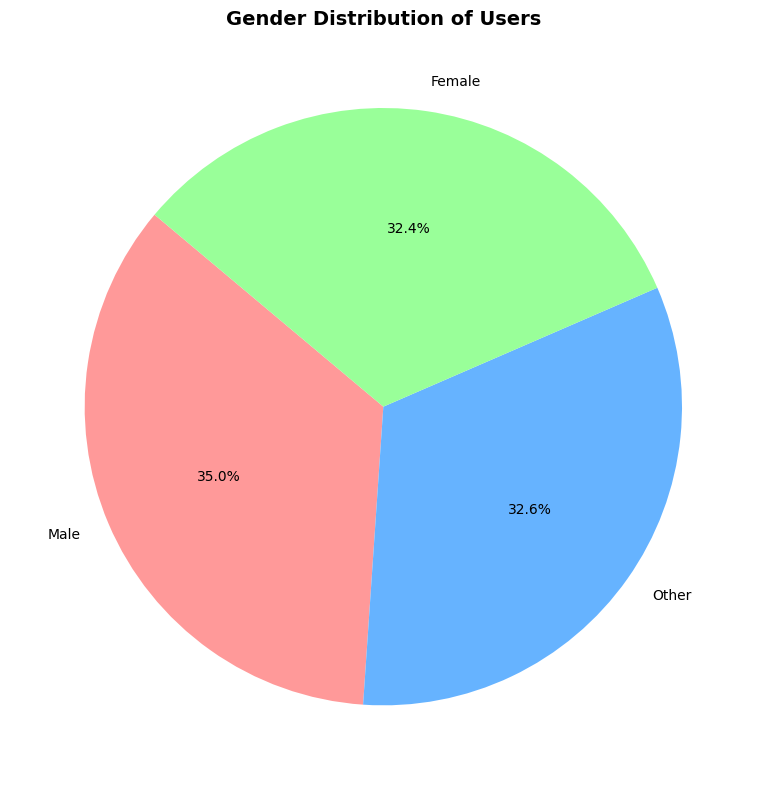

In [ ]:
import matplotlib.pyplot as plt

# Calculate gender distribution counts
gender_counts = df['gender'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    gender_counts,
    labels=gender_counts.index.str.capitalize(),
    autopct='%1.1f%%',
    startangle=140,
    colors=['#ff9999', '#66b3ff', '#99ff99']
)

plt.title('Gender Distribution of Users', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Histogram

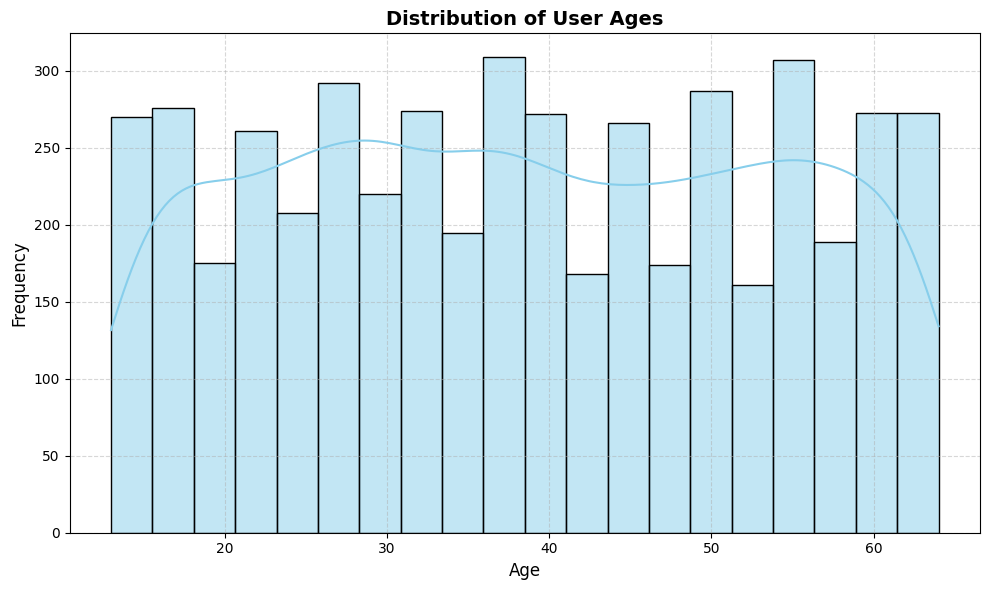

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram of the age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'].dropna(), bins=20, kde=True, color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Distribution of User Ages', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Display the plot
plt.tight_layout()
plt.show()

Box

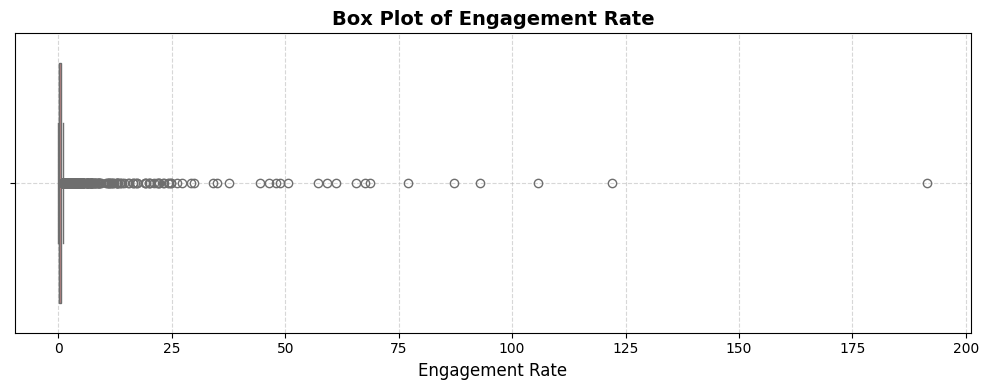

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot of the engagement rate
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['engagement_rate'], color='lightcoral')

# Add titles and labels
plt.title('Box Plot of Engagement Rate', fontsize=14, fontweight='bold')
plt.xlabel('Engagement Rate', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Display the plot
plt.tight_layout()
plt.show()

Seaborn  Count plot

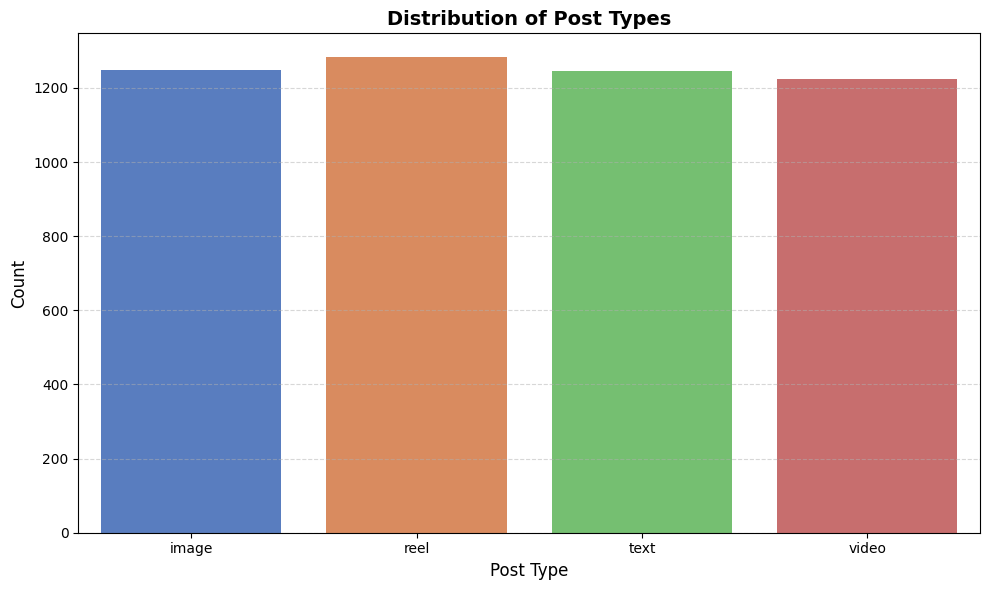

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a count plot for post_type
plt.figure(figsize=(10, 6))
sns.countplot(x='post_type', data=df, palette='muted', hue='post_type', legend=False)

# Add titles and labels
plt.title('Distribution of Post Types', fontsize=14, fontweight='bold')
plt.xlabel('Post Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Display the plot
plt.tight_layout()
plt.show()

Bar plot


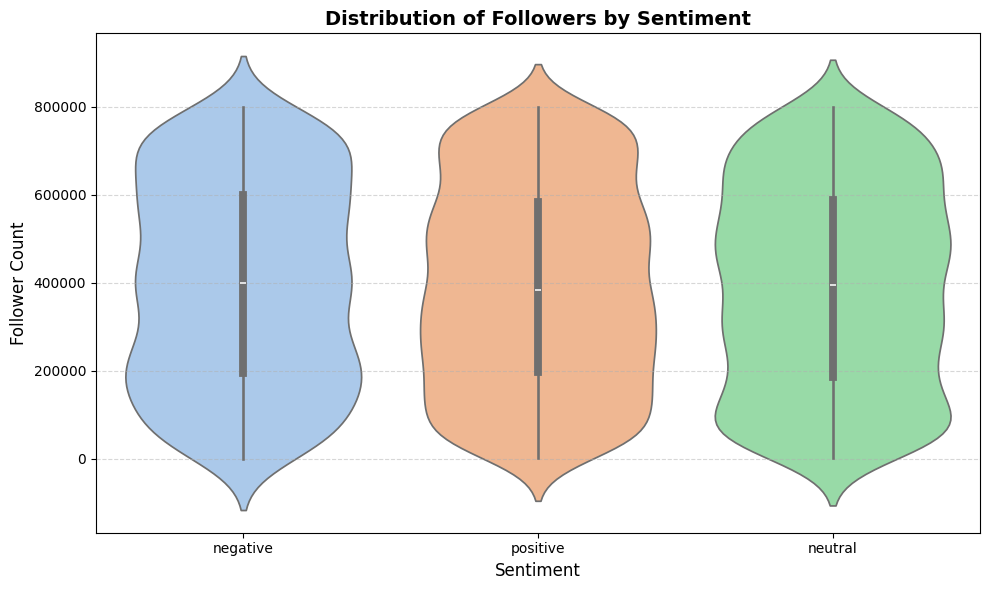

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a violin plot of follower_count by sentiment
plt.figure(figsize=(10, 6))
sns.violinplot(x='sentiment', y='follower_count', data=df, palette='pastel', hue='sentiment', legend=False)

# Add titles and labels
plt.title('Distribution of Followers by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Follower Count', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Display the plot
plt.tight_layout()
plt.show()

Violin

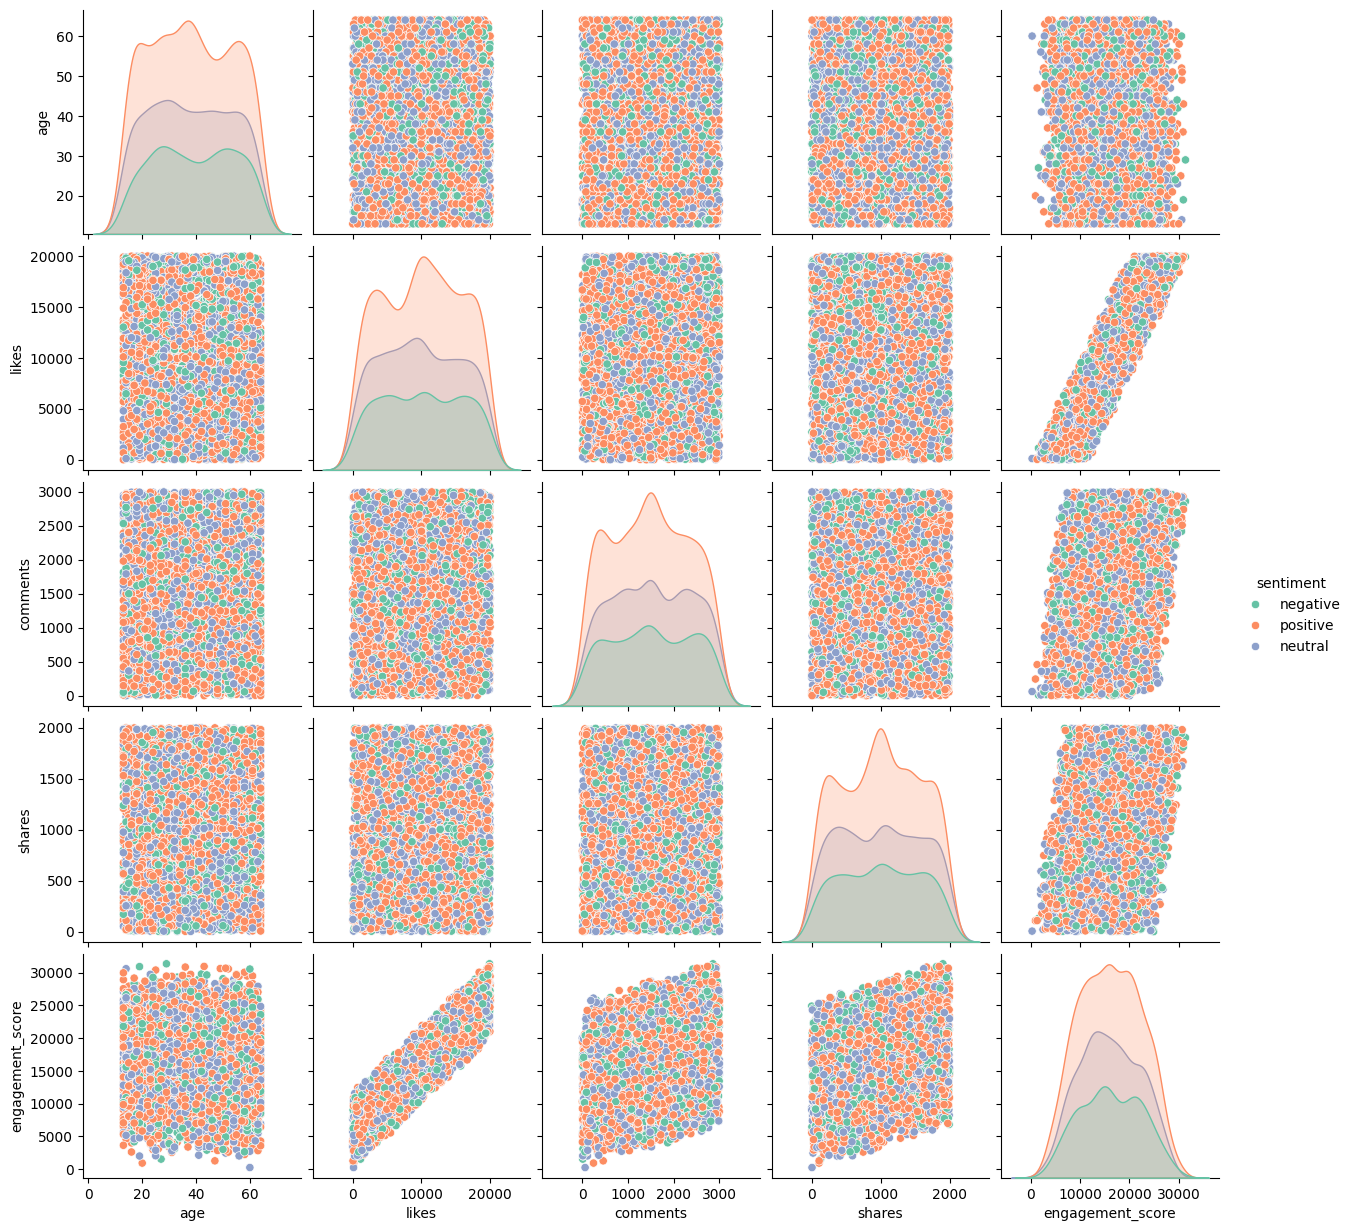

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting key numeric features for the pair plot
selected_numeric_cols = ['age', 'likes', 'comments', 'shares', 'engagement_score']

# Generate the pair plot, grouping by 'sentiment' for added depth
sns.pairplot(df[selected_numeric_cols + ['sentiment']].dropna(), hue='sentiment', palette='Set2', diag_kind='kde')

# Display the plot
plt.show()

Pair plot

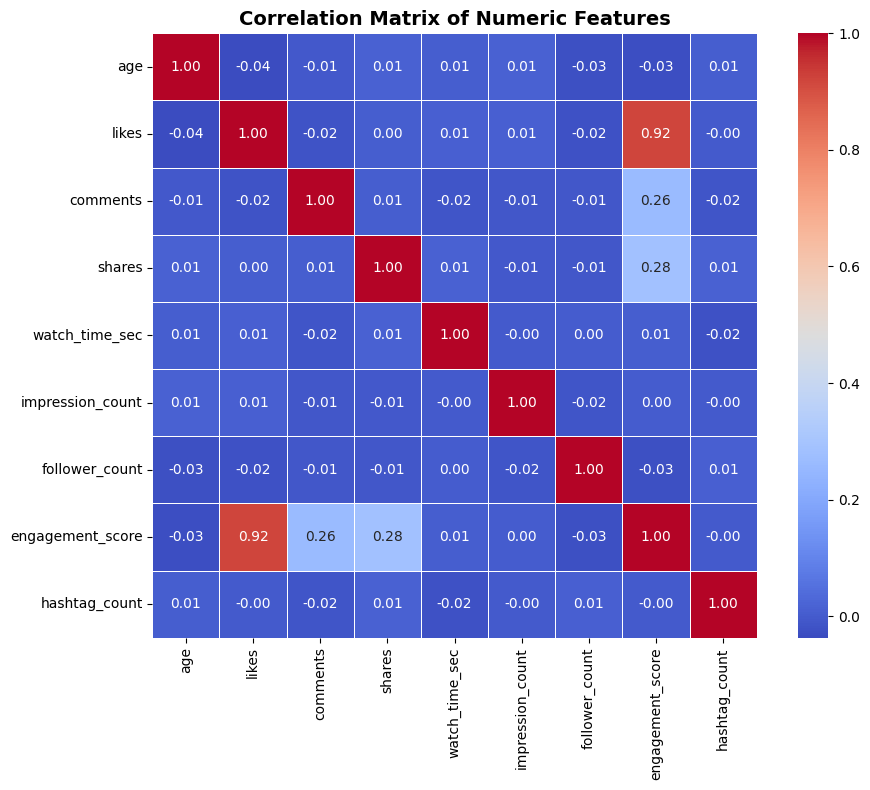

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the key numeric variables for the correlation matrix
numeric_cols = ['age', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'follower_count', 'engagement_score', 'hashtag_count']
corr_matrix = df[numeric_cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)

# Add title
plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')

# Display the plot
plt.tight_layout()
plt.show()

Heatmap

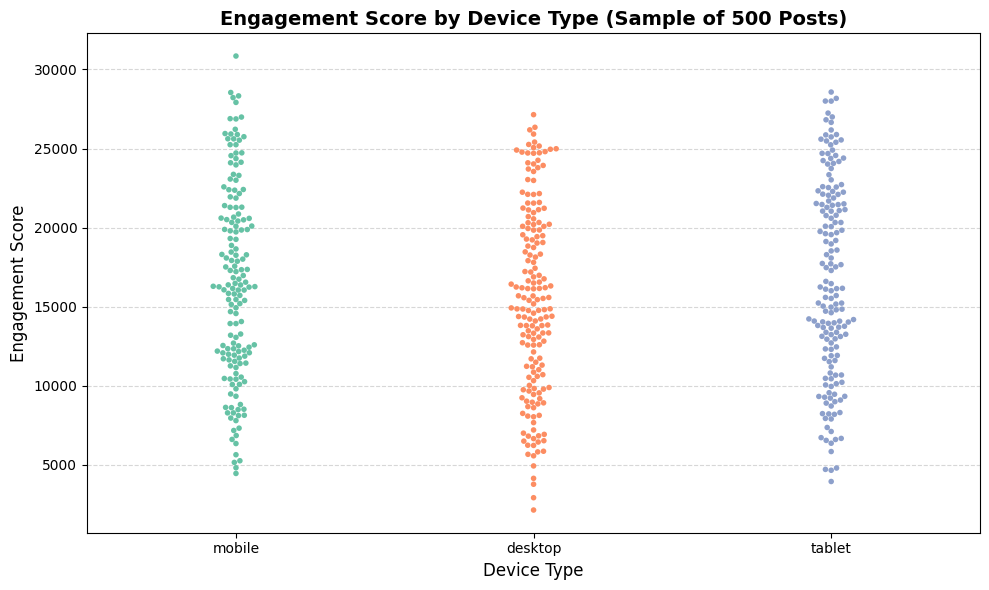

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample 500 rows to make the swarm plot readable and performant
df_sample = df.sample(n=500, random_state=42)

# Create a swarm plot
plt.figure(figsize=(10, 6))
sns.swarmplot(x='device_type', y='engagement_score', data=df_sample, palette='Set2', hue='device_type', legend=False, size=4)

# Add titles and labels
plt.title('Engagement Score by Device Type (Sample of 500 Posts)', fontsize=14, fontweight='bold')
plt.xlabel('Device Type', fontsize=12)
plt.ylabel('Engagement Score', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Display the plot
plt.tight_layout()
plt.show()


 Plotly (Interactive)

In [ ]:
import plotly.express as px

# Create an interactive bubble chart using a sample of 1000 rows for smooth performance
df_interactive = df.dropna(subset=['likes', 'impression_count', 'engagement_score', 'post_type']).sample(n=1000, random_state=42)

fig = px.scatter(
    df_interactive,
    x='likes',
    y='impression_count',
    size='engagement_score',
    color='post_type',
    hover_name='post_category',
    hover_data=['age', 'sentiment', 'device_type'],
    title='Interactive Analysis: Likes vs. Impressions (Size by Engagement Score)',
    labels={'likes': 'Likes', 'impression_count': 'Impressions', 'engagement_score': 'Engagement Score'},
    template='plotly_white',
    size_max=40
)

# Show the interactive figure
fig.show()

Final Insights should include the following analysis:

Which post types have the highest engagement?

In [ ]:
import pandas as pd

# Group by post type and compute mean engagement scores and rates
engagement_by_type = df.groupby('post_type')[['engagement_score', 'engagement_rate']].mean().reset_index()

# Sort by engagement_score in descending order
engagement_by_type = engagement_by_type.sort_values(by='engagement_score', ascending=False)

# Display the results
display(engagement_by_type)

# Print a summary answer
best_score_type = engagement_by_type.iloc[0]['post_type']
best_rate_type = df.groupby('post_type')['engagement_rate'].mean().idxmax()

print(f"\nBased on the data:")
print(f"- The post type with the highest average engagement score is '{best_score_type}'.")
print(f"- The post type with the highest average engagement rate is '{best_rate_type}'.")

,post_type,engagement_score,engagement_rate
0,image,16213.205293,0.895646
2,text,16140.328916,1.064549
3,video,16137.422857,1.122365
1,reel,15992.302806,0.783047



Based on the data:
- The post type with the highest average engagement score is 'image'.
- The post type with the highest average engagement rate is 'video'.


Best-performing content category?

In [ ]:
import pandas as pd

# Group by post_category and calculate average engagement metrics
category_engagement = df.groupby('post_category')[['engagement_score', 'engagement_rate']].mean().reset_index()

# Sort by engagement_score descending
category_engagement = category_engagement.sort_values(by='engagement_score', ascending=False)

# Display the category engagement overview
display(category_engagement)

# Get top performing categories
best_score_cat = category_engagement.iloc[0]['post_category']
best_rate_cat = df.groupby('post_category')['engagement_rate'].mean().idxmax()

print(f"\nBased on the analysis:")
print(f"- The content category with the highest average engagement score is '{best_score_cat}'.")
print(f"- The content category with the highest average engagement rate is '{best_rate_cat}'.")

,post_category,engagement_score,engagement_rate
5,music,16395.439370,0.888803
3,food,16255.679595,1.358628
6,tech,16210.778947,1.160475
4,lifestyle,16089.659802,1.091019
7,travel,16073.120833,0.702223
2,fitness,16043.028889,0.865628
0,education,16026.498415,0.844222
1,fashion,15852.008418,0.807109



Based on the analysis:
- The content category with the highest average engagement score is 'music'.
- The content category with the highest average engagement rate is 'food'.


Which countries have the highest average engagement rate?

In [ ]:
import pandas as pd

# Group by country and calculate the average engagement metrics
country_engagement = df.groupby('country')[['engagement_score', 'engagement_rate']].mean().reset_index()

# Sort by engagement_score descending
country_engagement = country_engagement.sort_values(by='engagement_score', ascending=False)

# Display the sorted country engagement table
display(country_engagement)

# Extract top performers
top_score_country = country_engagement.iloc[0]['country']
top_rate_country = df.groupby('country')['engagement_rate'].mean().idxmax()

print(f"\nBased on the analysis:")
print(f"- The country with the highest average engagement score is '{top_score_country.title()}'.")
print(f"- The country with the highest average engagement rate is '{top_rate_country.title()}'.")

,country,engagement_score,engagement_rate
3,france,16485.704637,1.146402
0,australia,16354.812373,1.324339
7,uae,16277.143141,1.112352
2,canada,16144.968811,0.916659
4,germany,16114.250000,0.759000
5,india,16058.251402,0.655005
6,japan,16027.786017,0.769623
9,usa,16023.702595,0.576580
1,brazil,15894.135913,1.540704
8,uk,15818.779919,0.850966



Based on the analysis:
- The country with the highest average engagement score is 'France'.
- The country with the highest average engagement rate is 'Brazil'.


User Trends

How age affects engagement

/tmp/ipykernel_4229/1336999653.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,age_group,engagement_score,engagement_rate
0,Teens (<20),16268.448437,0.839080
1,Young Adults (20-35),16277.784455,0.958594
2,Adults (36-50),16244.946925,0.985277
3,Seniors (51+),15661.644326,1.020729


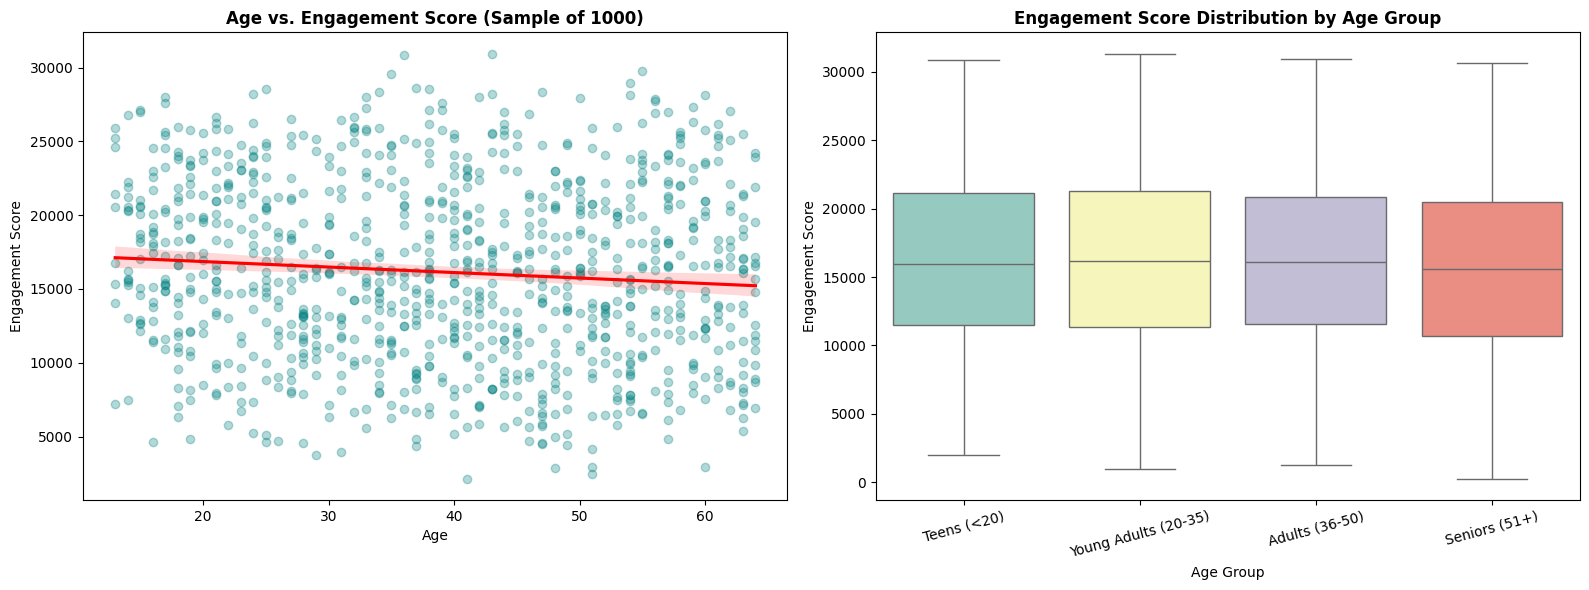

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by age_group (already defined in the dataset) and calculate average engagement metrics
age_group_engagement = df.groupby('age_group')[['engagement_score', 'engagement_rate']].mean().reset_index()
display(age_group_engagement)

# 2. Visualize with a trendline and a boxplot to see both general trends and distribution differences
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Regplot to show trend of engagement score across ages
sns.regplot(ax=axes[0], x='age', y='engagement_score', data=df.sample(n=1000, random_state=42),
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
axes[0].set_title('Age vs. Engagement Score (Sample of 1000)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Engagement Score')

# Right: Boxplot of engagement score across defined age groups
sns.boxplot(ax=axes[1], x='age_group', y='engagement_score', data=df, palette='Set3', hue='age_group', legend=False)
axes[1].set_title('Engagement Score Distribution by Age Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Engagement Score')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Performance difference for verified accounts

=== Performance Metrics by Verification Status ===


,is_verified,likes,comments,shares,engagement_score,engagement_rate
0,False,10137.201129,1505.511401,1001.599292,16153.021807,0.954744
1,True,9824.533126,1469.573499,1015.173913,15809.201863,1.054250


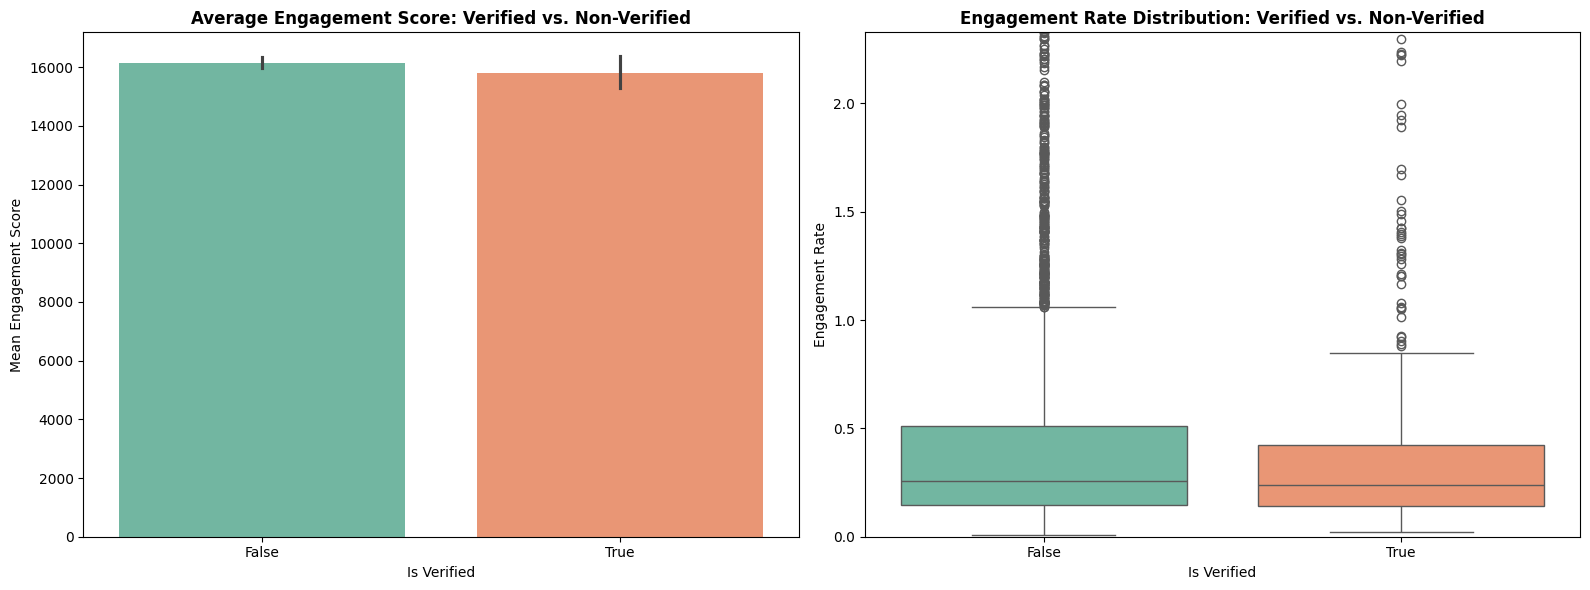

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by verification status and calculate averages
verification_summary = df.groupby('is_verified')[['likes', 'comments', 'shares', 'engagement_score', 'engagement_rate']].mean().reset_index()
print("=== Performance Metrics by Verification Status ===")
display(verification_summary)

# 2. Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Comparison of Engagement Score
sns.barplot(ax=axes[0], x='is_verified', y='engagement_score', data=df, palette='Set2', hue='is_verified', legend=False)
axes[0].set_title('Average Engagement Score: Verified vs. Non-Verified', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Is Verified')
axes[0].set_ylabel('Mean Engagement Score')

# Right: Comparison of Engagement Rate (log scaled or trimmed boxplot for better readability if outliers exist)
sns.boxplot(ax=axes[1], x='is_verified', y='engagement_rate', data=df, palette='Set2', hue='is_verified', legend=False)
axes[1].set_title('Engagement Rate Distribution: Verified vs. Non-Verified', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Is Verified')
axes[1].set_ylabel('Engagement Rate')
# Restrict y-limit slightly to focus on majority of data if there are massive outliers
axes[1].set_ylim(0, df['engagement_rate'].quantile(0.95))

plt.tight_layout()
plt.show()

Behavioral Insights

Does 'posted_at' contain hour/minute timestamps? False
It seems the 'posted_at' column only contains date information without specific hours.


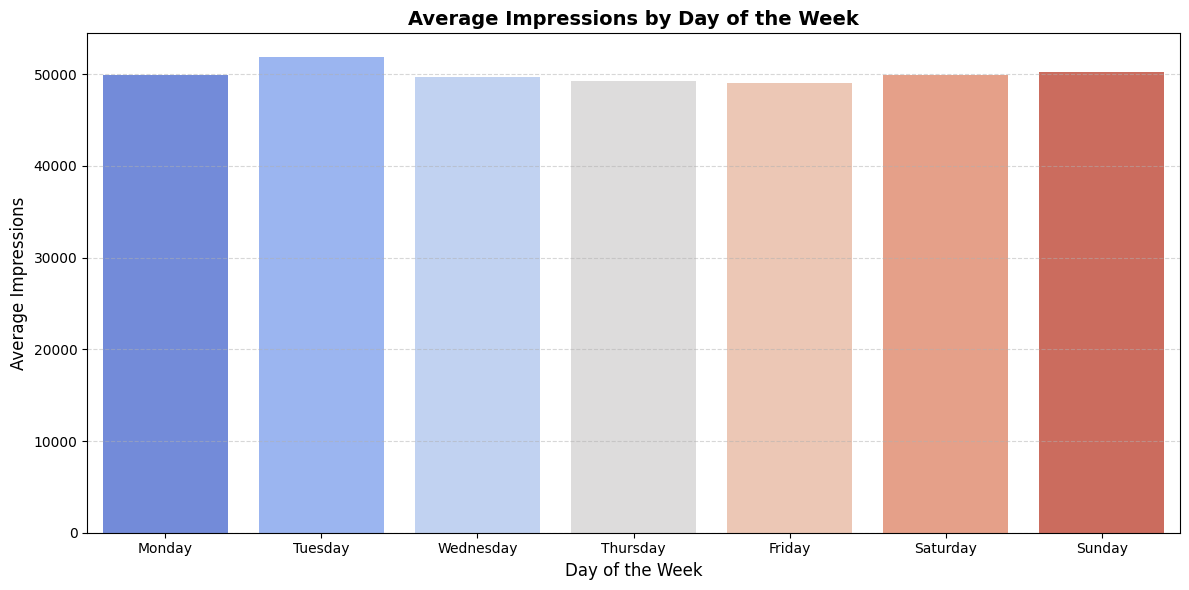

Since hour-level timestamps are not available, we analyzed weekly patterns: The best day of the week for impressions is Tuesday.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Let's inspect the formats in 'posted_at' or check if there's any time component
# Since 'posted_at' might only contain dates in some rows, let's convert and check if we have hour data.
# If no hour is present, we can look at the distribution of 'watch_time_sec' or look at the day of the week.

# Check if any string contains actual time (like HH:MM or HH:MM:SS)
has_time = df['posted_at'].astype(str).str.contains(':').any()
print(f"Does 'posted_at' contain hour/minute timestamps? {has_time}")

if has_time:
    # Try to parse datetime with time component
    df['posted_datetime'] = pd.to_datetime(df['posted_at'], errors='coerce')
    df['hour'] = df['posted_datetime'].dt.hour

    # Group by hour and calculate mean impressions
    hourly_impressions = df.groupby('hour')['impression_count'].mean().reset_index()

    # Plot hourly trend
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='hour', y='impression_count', data=hourly_impressions, marker='o', color='darkorange', linewidth=2.5)
    plt.title('Average Impressions by Hour of Day', fontsize=14, fontweight='bold')
    plt.xlabel('Hour of Day (24-hour format)', fontsize=12)
    plt.ylabel('Average Impressions', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(range(0, 24))
    plt.tight_layout()
    plt.show()

    best_hour = hourly_impressions.loc[hourly_impressions['impression_count'].idxmax()]['hour']
    print(f"The best hour of the day for impressions is {int(best_hour)}:00.")
else:
    print("It seems the 'posted_at' column only contains date information without specific hours.")
    # As an alternative, let's analyze the day of the week to see which day yields the most impressions
    df['posted_date_parsed'] = pd.to_datetime(df['posted_at'], format='mixed', errors='coerce')
    df['day_of_week'] = df['posted_date_parsed'].dt.day_name()

    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    daily_impressions = df.groupby('day_of_week')['impression_count'].mean().reindex(day_order).reset_index()

    plt.figure(figsize=(12, 6))
    sns.barplot(x='day_of_week', y='impression_count', data=daily_impressions, palette='coolwarm', hue='day_of_week', legend=False)
    plt.title('Average Impressions by Day of the Week', fontsize=14, fontweight='bold')
    plt.xlabel('Day of the Week', fontsize=12)
    plt.ylabel('Average Impressions', fontsize=12)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    best_day = daily_impressions.loc[daily_impressions['impression_count'].idxmax()]['day_of_week']
    print(f"Since hour-level timestamps are not available, we analyzed weekly patterns: The best day of the week for impressions is {best_day}.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by device_type and calculate average watch time
device_watch_time = df.groupby('device_type')['watch_time_sec'].mean().reset_index()
print("=== Average Watch Time by Device Type ===")
display(device_watch_time)

# 2. Visualize distributions and averages
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Bar plot for Mean Watch Time
sns.barplot(ax=axes[0], x='device_type', y='watch_time_sec', data=df, palette='Set2', hue='device_type', legend=False, errorbar=None)
axes[0].set_title('Average Watch Time by Device Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Device Type')
axes[0].set_ylabel('Mean Watch Time (seconds)')

# Right: Box plot to show full distribution of watch time
sns.boxplot(ax=axes[1], x='device_type', y='watch_time_sec', data=df, palette='Set2', hue='device_type', legend=False)
axes[1].set_title('Watch Time Distribution by Device Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Device Type')
axes[1].set_ylabel('Watch Time (seconds)')

plt.tight_layout()
plt.show()

Sentiment Analysis

=== Performance Metrics by Sentiment ===


,sentiment,engagement_score,engagement_rate
0,negative,16262.208333,1.038486
1,neutral,15969.698101,0.991170
2,positive,16127.371985,0.954800


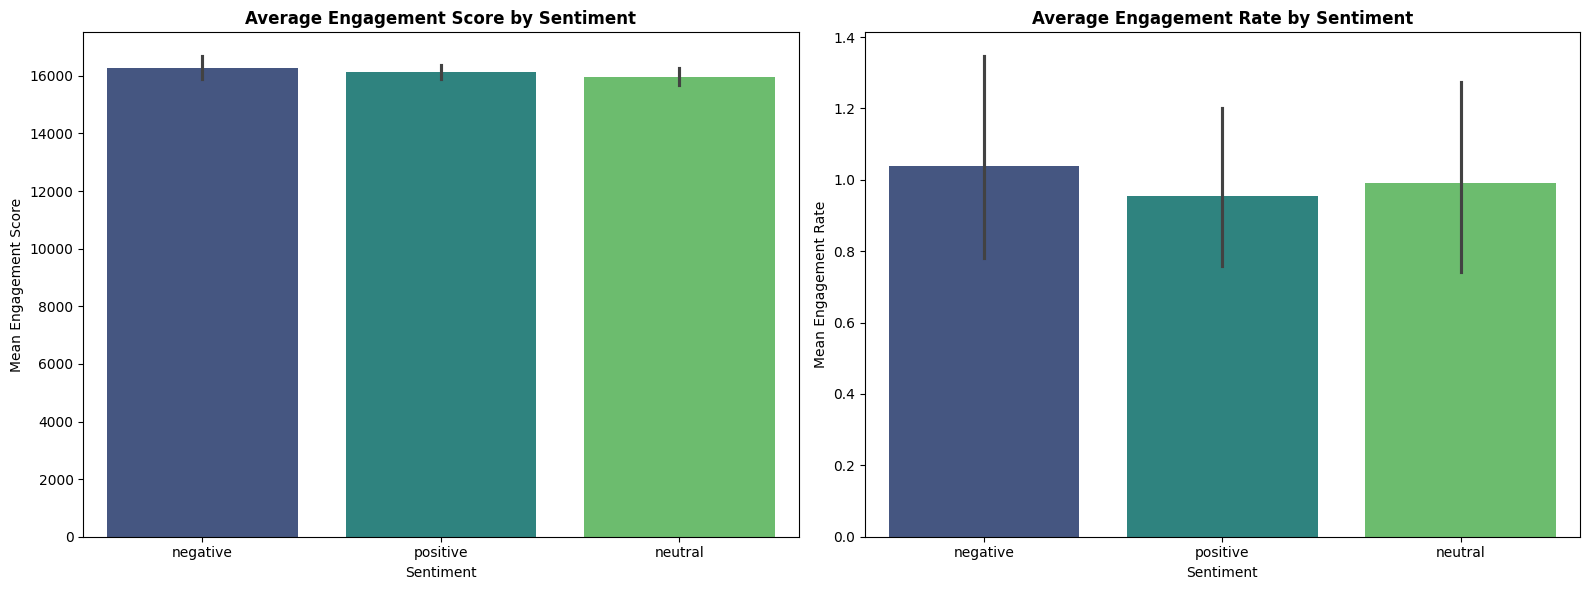

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by sentiment and calculate average engagement metrics
sentiment_performance = df.groupby('sentiment')[['engagement_score', 'engagement_rate']].mean().reset_index()
print("=== Performance Metrics by Sentiment ===")
display(sentiment_performance)

# 2. Visualize the engagement score and rate by sentiment
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Average Engagement Score by Sentiment
sns.barplot(ax=axes[0], x='sentiment', y='engagement_score', data=df, palette='viridis', hue='sentiment', legend=False)
axes[0].set_title('Average Engagement Score by Sentiment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Mean Engagement Score')

# Right: Average Engagement Rate by Sentiment
sns.barplot(ax=axes[1], x='sentiment', y='engagement_rate', data=df, palette='viridis', hue='sentiment', legend=False)
axes[1].set_title('Average Engagement Rate by Sentiment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Mean Engagement Rate')

plt.tight_layout()
plt.show()

=== Average Behavior by Sentiment Category ===


,sentiment,likes,comments,shares,watch_time_sec,engagement_score
0,negative,10208.096875,1516.094792,1007.307292,4054.639583,16262.208333
1,neutral,9923.194499,1528.404060,996.565160,4031.823183,15969.698101
2,positive,10156.926788,1482.401608,1001.880660,3980.731274,16127.371985


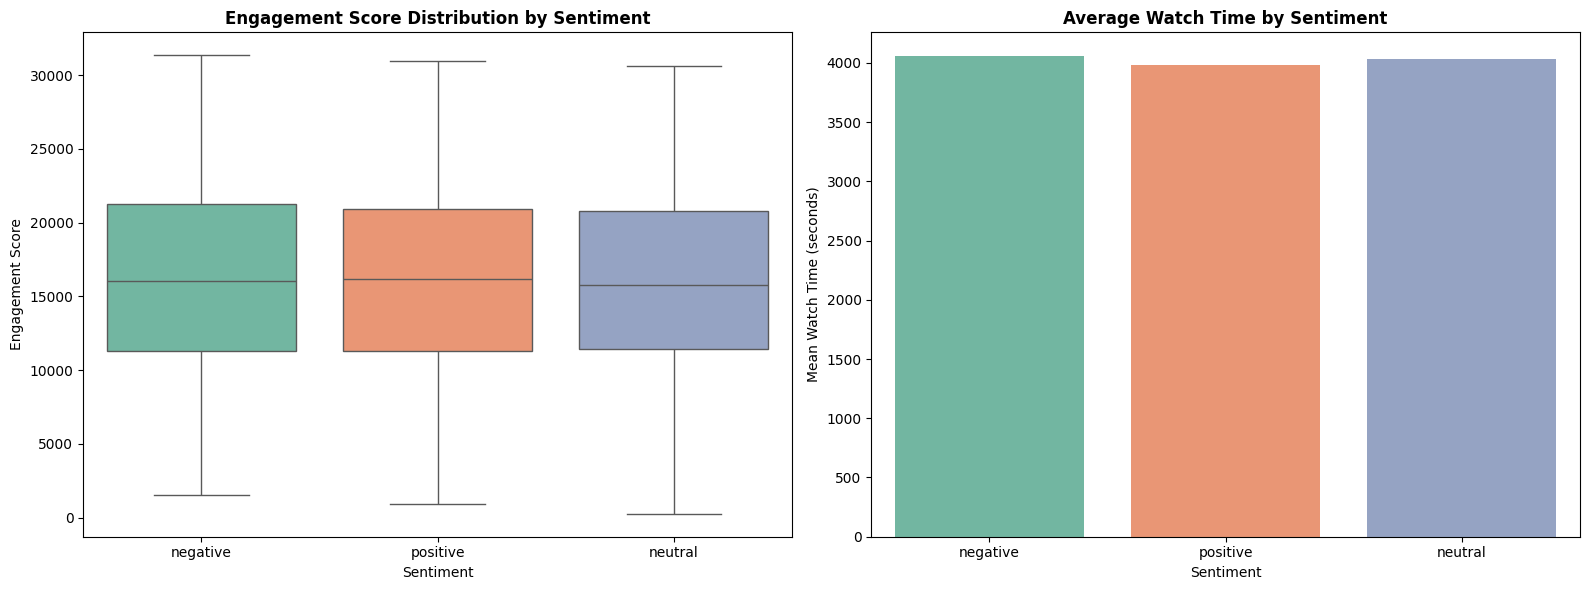

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate descriptive statistics for engagement metrics grouped by sentiment
sentiment_behavior = df.groupby('sentiment')[['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_score']].mean().reset_index()
print("=== Average Behavior by Sentiment Category ===")
display(sentiment_behavior)

# 2. Visualize comparison of negative and neutral post behavior
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Distribution of engagement scores across sentiments
sns.boxplot(ax=axes[0], x='sentiment', y='engagement_score', data=df, palette='Set2', hue='sentiment', legend=False)
axes[0].set_title('Engagement Score Distribution by Sentiment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Engagement Score')

# Right: Average watch time by sentiment to see if negative/neutral posts retain users longer
sns.barplot(ax=axes[1], x='sentiment', y='watch_time_sec', data=df, palette='Set2', hue='sentiment', legend=False, errorbar=None)
axes[1].set_title('Average Watch Time by Sentiment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Mean Watch Time (seconds)')

plt.tight_layout()
plt.show()